In [491]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.weights import Queen
from scipy.optimize import nnls

ROOT = Path(
    r"C:\Users\pd006\Desktop\internship_search\sdm-car"
).resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# ------------------------------------------------------------
# Geographic configuration
# ------------------------------------------------------------
STATE_ABBR = "nc"  #"mi"  #"nv" #"ar" #ca
STATE_FIPS = "37"  #"26"  #"32"  #"05" #06

COUNTY_NAME = "Wake"  #"Wayne"  #"Clark"  #"Los Angeles" #"Washington" #San Bernardino
COUNTY_FIPS = "183"  #"163"  #"003"  #"037" # "143" #071

DATA_YEAR = 2023  #2021 #2023
TRACT_VINTAGE = 2024

FULL_COUNTY_FIPS = STATE_FIPS + COUNTY_FIPS

COUNTY_SLUG = (
    COUNTY_NAME
    .lower()
    .replace(" ", "_")
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
RAW_DIR = ROOT / "data" / "raw" / "lodes"
PROCESSED_DIR = ROOT / "data" / "processed" / "lodes"

WAC_PATH = (
    RAW_DIR
    / f"{STATE_ABBR}_wac_S000_JT00_{DATA_YEAR}.csv.gz"
)

XWALK_PATH = (
    RAW_DIR
    / f"{STATE_ABBR}_xwalk.csv.gz"
)

TRACT_PATH = (
    RAW_DIR
    / f"tl_{TRACT_VINTAGE}_{STATE_FIPS}_tract.zip"
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

for path in [WAC_PATH, XWALK_PATH, TRACT_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

print("State:", STATE_ABBR)
print("County:", COUNTY_NAME)
print("Full county FIPS:", FULL_COUNTY_FIPS)
print("All input files found.")

State: nc
County: Wake
Full county FIPS: 37183
All input files found.


In [492]:
SECTOR_MAP = {
    "CNS01": "agriculture",
    "CNS02": "mining",
    "CNS03": "utilities",
    "CNS04": "construction",
    "CNS05": "manufacturing",
    "CNS06": "wholesale",
    "CNS07": "retail",
    "CNS08": "transport",
    "CNS09": "information",
    "CNS10": "finance",
    "CNS11": "real_estate",
    "CNS12": "professional",
    "CNS13": "management",
    "CNS14": "admin_waste",
    "CNS15": "education",
    "CNS16": "healthcare",
    "CNS17": "arts_recreation",
    "CNS18": "hospitality",
    "CNS19": "other_services",
    "CNS20": "public_admin",
}

industry_codes = list(SECTOR_MAP.keys())

print("Number of industry sectors:", len(industry_codes))

Number of industry sectors: 20


In [493]:
wac = pd.read_csv(
    WAC_PATH,
    compression="gzip",
    usecols=[
        "w_geocode",
        "C000",
        *industry_codes,
    ],
    dtype={
        "w_geocode": "string",
    },
)

wac["w_geocode"] = (
    wac["w_geocode"]
    .str.zfill(15)
)

rename_columns = {
    "C000": "total_jobs",
    **{
        code: f"{name}_jobs"
        for code, name in SECTOR_MAP.items()
    },
}

wac = wac.rename(columns=rename_columns)

print("WAC rows:", len(wac))
print("WAC columns:", len(wac.columns))

display(wac.head())

WAC rows: 74734
WAC columns: 22


,w_geocode,total_jobs,agriculture_jobs,mining_jobs,utilities_jobs,construction_jobs,manufacturing_jobs,wholesale_jobs,retail_jobs,transport_jobs,...,real_estate_jobs,professional_jobs,management_jobs,admin_waste_jobs,education_jobs,healthcare_jobs,arts_recreation_jobs,hospitality_jobs,other_services_jobs,public_admin_jobs
0,370010201001001,4,0,0,0,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1,370010201001007,2,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,370010201001008,7,0,0,0,0,0,0,0,0,...,0,7,0,0,0,0,0,0,0,0
3,370010201001010,2,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
4,370010201001011,3,0,0,0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [494]:
xwalk = pd.read_csv(
    XWALK_PATH,
    compression="gzip",
    usecols=[
        "tabblk2020",
        "cty",
        "trct",
    ],
    dtype="string",
)

xwalk["tabblk2020"] = (
    xwalk["tabblk2020"]
    .str.zfill(15)
)

xwalk["cty"] = (
    xwalk["cty"]
    .str.zfill(5)
)

xwalk["trct"] = (
    xwalk["trct"]
    .str.zfill(11)
)

#LA_COUNTY_FIPS = "06037"

xwalk_county = xwalk.loc[
    xwalk["cty"] == FULL_COUNTY_FIPS
].copy()

print(f"{COUNTY_NAME} County blocks:", len(xwalk_county))
print(
    f"{COUNTY_NAME} County tracts:",
    xwalk_county["trct"].nunique(),
)

Wake County blocks: 14470
Wake County tracts: 230


In [495]:
jobs_county = wac.merge(
    xwalk_county[
        [
            "tabblk2020",
            "trct",
        ]
    ],
    left_on="w_geocode",
    right_on="tabblk2020",
    how="inner",
    validate="one_to_one",
)

print(
    f"{COUNTY_NAME} workplace blocks:",
    len(jobs_county),
)

print(
    f"{COUNTY_NAME} tracts represented:",
    jobs_county["trct"].nunique(),
)

Wake workplace blocks: 7147
Wake tracts represented: 230


In [496]:
job_columns = [
    "total_jobs",
    *[
        f"{name}_jobs"
        for name in SECTOR_MAP.values()
    ],
]

tract_jobs = (
    jobs_county
    .groupby("trct", as_index=False)[job_columns]
    .sum()
)

print("Aggregated tract rows:", len(tract_jobs))
display(tract_jobs.head())

Aggregated tract rows: 230


,trct,total_jobs,agriculture_jobs,mining_jobs,utilities_jobs,construction_jobs,manufacturing_jobs,wholesale_jobs,retail_jobs,transport_jobs,...,real_estate_jobs,professional_jobs,management_jobs,admin_waste_jobs,education_jobs,healthcare_jobs,arts_recreation_jobs,hospitality_jobs,other_services_jobs,public_admin_jobs
0,37183050100,46283,0,0,285,767,174,1444,421,162,...,491,10902,684,4515,387,322,256,2642,894,18470
1,37183050300,4477,41,0,0,123,19,260,173,41,...,129,893,100,152,160,192,78,1446,321,1
2,37183050400,2777,0,0,0,166,210,113,180,271,...,61,175,20,278,372,108,74,373,135,120
3,37183050500,1884,0,0,0,138,37,230,119,0,...,34,139,26,107,72,234,13,218,293,0
4,37183050600,787,0,0,0,0,13,11,12,0,...,14,39,0,1,452,64,6,149,20,0


In [497]:
for sector_name in SECTOR_MAP.values():
    jobs_col = f"{sector_name}_jobs"
    response_col = f"{sector_name}_concentration"

    sector_jobs = tract_jobs[jobs_col]
    nonsector_jobs = tract_jobs["total_jobs"] - sector_jobs

    if (nonsector_jobs < 0).any():
        raise ValueError(
            f"{jobs_col} exceeds total_jobs."
        )

    tract_jobs[response_col] = np.log(
        (sector_jobs + 0.5)
        /
        (nonsector_jobs + 0.5)
    )

In [498]:
tract_jobs["industrial_jobs"] = (
    tract_jobs["manufacturing_jobs"]
    + tract_jobs["transport_jobs"]
)

tract_jobs["industrial_concentration"] = np.log(
    (tract_jobs["industrial_jobs"] + 0.5)
    /
    (
        tract_jobs["total_jobs"]
        - tract_jobs["industrial_jobs"]
        + 0.5
    )
)

print("Concentration responses created.")

Concentration responses created.


In [499]:
tracts = gpd.read_file(TRACT_PATH)

tracts["GEOID"] = (
    tracts["GEOID"]
    .astype("string")
    .str.zfill(11)
)

tracts["COUNTYFP"] = (
    tracts["COUNTYFP"]
    .astype("string")
    .str.zfill(3)
)

tracts_county = tracts.loc[
    tracts["COUNTYFP"] == COUNTY_FIPS
].copy()

gdf = tracts_county.merge(
    tract_jobs,
    left_on="GEOID",
    right_on="trct",
    how="inner",
    validate="one_to_one",
)

print(
    f"{COUNTY_NAME} tract polygons:",
    len(tracts_county),
)

print(
    "Tracts with workplace data:",
    len(gdf),
)

print("CRS:", gdf.crs)

Wake tract polygons: 230
Tracts with workplace data: 230
CRS: EPSG:4269


In [500]:
MIN_TOTAL_JOBS = 50

gdf = (
    gdf.loc[
        gdf["total_jobs"] >= MIN_TOTAL_JOBS
    ]
    .copy()
    .reset_index(drop=True)
)

print("Tracts after employment filter:", len(gdf))

Tracts after employment filter: 229


In [501]:
queen_initial = Queen.from_dataframe(
    gdf,
    use_index=True,
)

gdf["component"] = np.asarray(
    queen_initial.component_labels
)

print("Component sizes:")
print(
    gdf["component"]
    .value_counts()
    .sort_values(ascending=False)
)

Component sizes:
component
0    229
Name: count, dtype: int64


In [502]:
largest_component = (
    gdf["component"]
    .value_counts()
    .idxmax()
)

gdf = (
    gdf.loc[
        gdf["component"] == largest_component
    ]
    .drop(columns="component")
    .reset_index(drop=True)
)

queen = Queen.from_dataframe(
    gdf,
    use_index=True,
)

print("Final tracts:", len(gdf))
print("Connected components:", queen.n_components)
print("Islands:", queen.islands)

assert queen.n_components == 1
assert len(queen.islands) == 0

Final tracts: 229
Connected components: 1
Islands: []


In [ ]:
Y_COL =  "professional_concentration" #"manufacturing_concentration"  #"hospitality_concentration" #"transport_concentration" #"information_concentration"  # "retail_concentration" #"industrial_concentration"

print("Selected response:", Y_COL)
print(gdf[Y_COL].describe())

Selected response: manufacturing_concentration
count    229.000000
mean      -4.882165
std        1.979682
min      -10.683798
25%       -6.208590
50%       -4.901850
75%       -3.498342
max       -0.428108
Name: manufacturing_concentration, dtype: float64


In [504]:
recommended_responses = [
    "transport_concentration",
    "manufacturing_concentration",
    "industrial_concentration",
    "retail_concentration",
    "information_concentration",
    "professional_concentration",
    "healthcare_concentration",
    "hospitality_concentration",
]

print("\nRecommended responses:")
for name in recommended_responses:
    print(name)


Recommended responses:
transport_concentration
manufacturing_concentration
industrial_concentration
retail_concentration
information_concentration
professional_concentration
healthcare_concentration
hospitality_concentration


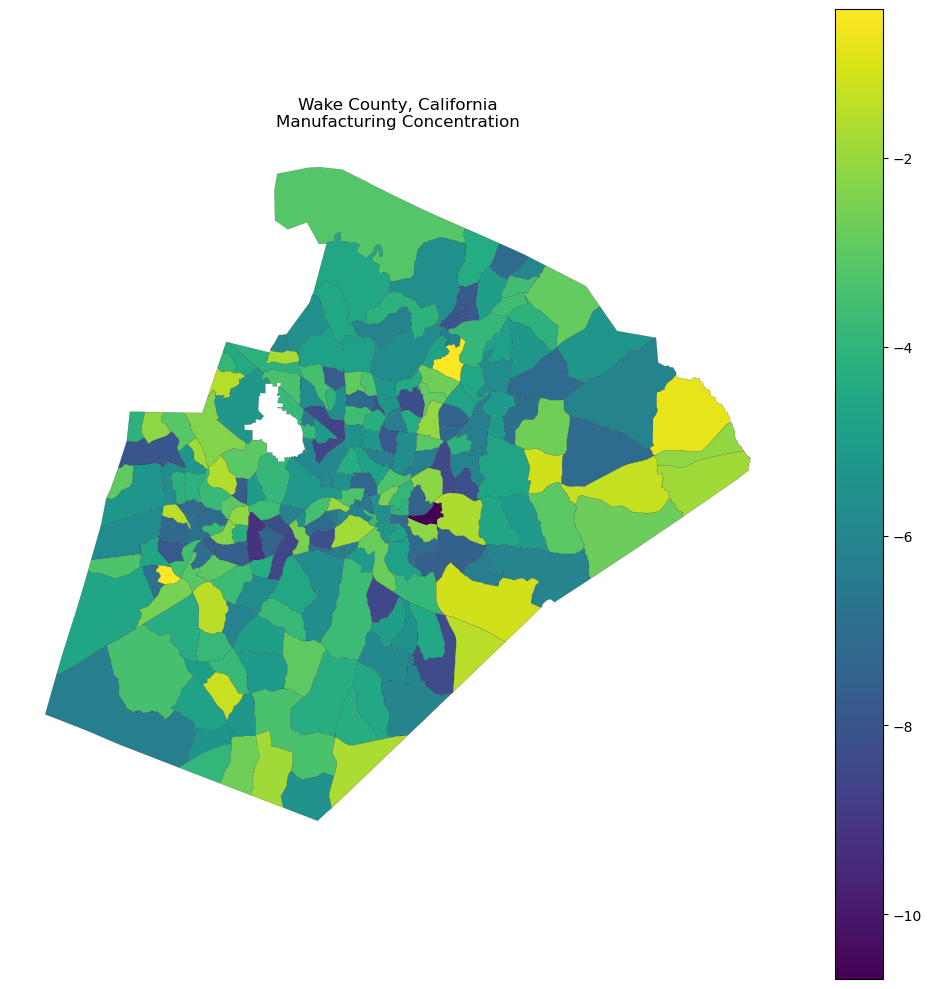

In [505]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    column=Y_COL,
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.1,
)

ax.set_title(
    f"{COUNTY_NAME} County, California\n"
    f"{Y_COL.replace('_', ' ').title()}"
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

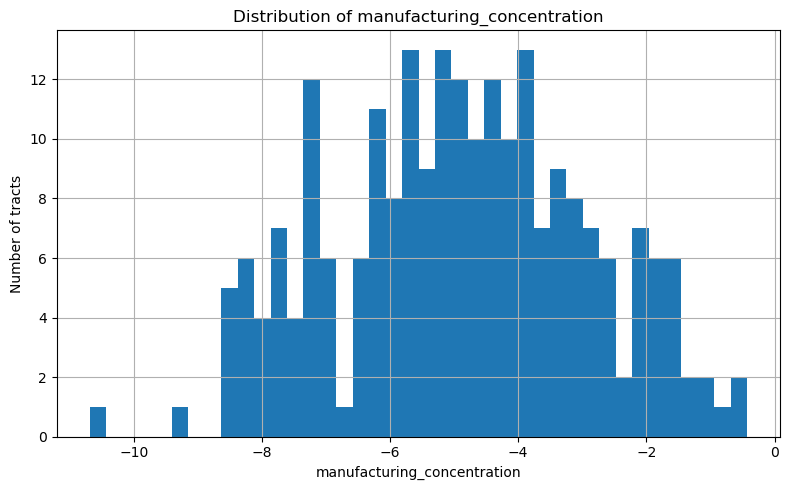

In [518]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

gdf[Y_COL].hist(
    bins=40,
    ax=ax,
)

ax.set_title(
    f"Distribution of {Y_COL}"
)

ax.set_xlabel(Y_COL)
ax.set_ylabel("Number of tracts")

plt.tight_layout()
plt.show()

In [507]:
GPKG_PATH = (
    PROCESSED_DIR
    / (
        f"{STATE_ABBR}_{COUNTY_SLUG}_"
        f"lodes_{DATA_YEAR}_sector_concentrations.gpkg"
    )
)

CSV_PATH = (
    PROCESSED_DIR
    / (
        f"{STATE_ABBR}_{COUNTY_SLUG}_"
        f"lodes_{DATA_YEAR}_sector_concentrations.csv"
    )
)

gdf.to_file(
    GPKG_PATH,
    layer="tracts",
    driver="GPKG",
)

gdf.drop(columns="geometry").to_csv(
    CSV_PATH,
    index=False,
)

print("Saved:")
print(GPKG_PATH)
print(CSV_PATH)

Saved:
C:\Users\pd006\Desktop\internship_search\sdm-car\data\processed\lodes\nc_wake_lodes_2023_sector_concentrations.gpkg
C:\Users\pd006\Desktop\internship_search\sdm-car\data\processed\lodes\nc_wake_lodes_2023_sector_concentrations.csv


In [508]:
y_raw = gdf[Y_COL].to_numpy(
    dtype=float
)

y_mean = y_raw.mean()
y_sd = y_raw.std(ddof=1)

if y_sd <= 0:
    raise ValueError(
        f"{Y_COL} has zero variance."
    )

y = (
    y_raw - y_mean
) / y_sd

print("Standardized mean:", y.mean())
print("Standardized SD:", y.std(ddof=1))

Standardized mean: -4.1500039697778775e-16
Standardized SD: 0.9999999999999999


In [509]:
A = queen.sparse.toarray().astype(float)

A = np.maximum(A, A.T)
np.fill_diagonal(A, 0.0)

degree = A.sum(axis=1)

D = np.diag(degree)
L = D - A

print("Adjacency shape:", A.shape)
print("Minimum degree:", degree.min())
print("Maximum degree:", degree.max())
print("Laplacian symmetric:", np.allclose(L, L.T))

Adjacency shape: (229, 229)
Minimum degree: 2.0
Maximum degree: 11.0
Laplacian symmetric: True


In [510]:
eigenvalues, eigenvectors = np.linalg.eigh(L)

number_zero = np.sum(
    eigenvalues < 1e-8
)

print("Smallest eigenvalues:")
print(eigenvalues[:10])

print("Largest eigenvalue:", eigenvalues[-1])
print("Zero eigenvalues:", number_zero)

assert number_zero == 1

Smallest eigenvalues:
[-8.04541453e-16  6.76284475e-02  1.56076985e-01  2.24911920e-01
  2.91758933e-01  4.32503474e-01  4.63377500e-01  4.84993750e-01
  6.41871265e-01  6.55568777e-01]
Largest eigenvalue: 12.395657261716934
Zero eigenvalues: 1


In [511]:
modal_coefficients = (
    eigenvectors.T @ y
)

# Remove the constant eigenvector.
lam = eigenvalues[1:]

modal_energy = (
    modal_coefficients[1:] ** 2
)

print("Positive-frequency modes:", len(lam))
print("Total modal energy:", modal_energy.sum())

Positive-frequency modes: 228
Total modal energy: 228.00000000000006


In [512]:
X_car = np.column_stack(
    [
        1.0 / lam,
        np.ones_like(lam),
    ]
)

car_parameters, residual_norm = nnls(
    X_car,
    modal_energy,
)

tau2_hat = car_parameters[0]
sigma2_hat = car_parameters[1]

car_energy = (
    tau2_hat / lam
    + sigma2_hat
)

print("Selected response:", Y_COL)
print("Estimated tau^2:", tau2_hat)
print("Estimated sigma^2:", sigma2_hat)
print("NNLS residual norm:", residual_norm)

Selected response: manufacturing_concentration
Estimated tau^2: 0.09066391777601857
Estimated sigma^2: 0.9641660668328959
NNLS residual norm: 22.050656436857334


In [513]:
N_BANDS = 25

mode_groups = np.array_split(
    np.arange(len(lam)),
    N_BANDS,
)

band_lambda = np.array(
    [
        np.mean(lam[index])
        for index in mode_groups
    ]
)

band_observed = np.array(
    [
        np.mean(modal_energy[index])
        for index in mode_groups
    ]
)

band_car = np.array(
    [
        np.mean(car_energy[index])
        for index in mode_groups
    ]
)

ratio = band_observed / band_car

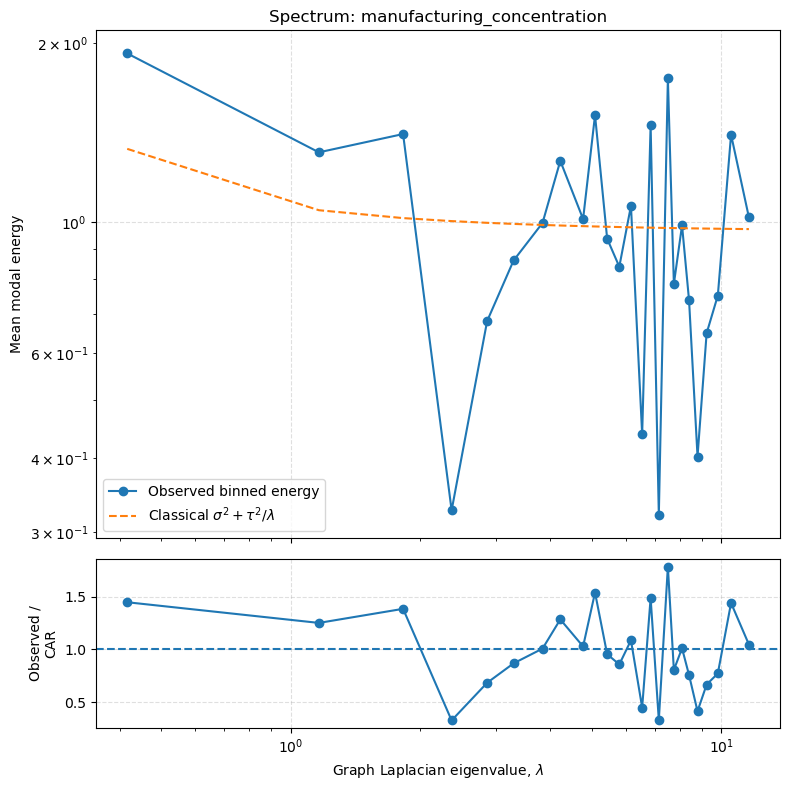

In [514]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3, 1]
    },
)

ax = axes[0]
ax_ratio = axes[1]

ax.plot(
    band_lambda,
    band_observed,
    marker="o",
    label="Observed binned energy",
)

ax.plot(
    band_lambda,
    band_car,
    linestyle="--",
    label=r"Classical $\sigma^2+\tau^2/\lambda$",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel("Mean modal energy")
ax.set_title(
    f"Spectrum: {Y_COL}"
)
ax.legend()
ax.grid(
    True,
    linestyle="--",
    alpha=0.4,
)

ax_ratio.plot(
    band_lambda,
    ratio,
    marker="o",
)

ax_ratio.axhline(
    1.0,
    linestyle="--",
)

ax_ratio.set_xscale("log")
ax_ratio.set_xlabel(
    r"Graph Laplacian eigenvalue, $\lambda$"
)
ax_ratio.set_ylabel(
    "Observed /\nCAR"
)

ax_ratio.grid(
    True,
    linestyle="--",
    alpha=0.4,
)

plt.tight_layout()
plt.show()

In [515]:
spectral_summary = pd.DataFrame(
    {
        "band": np.arange(
            1,
            N_BANDS + 1,
        ),
        "mean_lambda": band_lambda,
        "observed_energy": band_observed,
        "car_reference": band_car,
        "observed_to_car_ratio": ratio,
    }
)

display(spectral_summary)

,band,mean_lambda,observed_energy,car_reference,observed_to_car_ratio
0,1,0.416590,1.921707,1.327014,1.448144
1,2,1.161697,1.309241,1.045861,1.251830
2,3,1.822672,1.405449,1.014392,1.385508
3,4,2.363194,0.326441,1.002661,0.325574
4,5,2.857863,0.680411,0.995971,0.683163
5,6,3.292277,0.860546,0.991735,0.867718
6,7,3.843860,0.995579,0.987788,1.007888
7,8,4.226994,1.266543,0.985633,1.285005
8,9,4.775242,1.010648,0.983171,1.027947
9,10,5.089930,1.512401,0.981983,1.540149
